# 2D Likelihood Landscape: Pulsar 0 Distance vs Pulsar 1 Distance

This notebook generates **N** random pulsars and one continuous gravitational
wave (CGW) source, then sweeps the PTA log-likelihood over a 2D grid of:

- **Pulsar 0 distance** (`PX`, in kpc) along the x-axis
- **Pulsar 1 distance** (`PX`, in kpc) along the y-axis

All other pulsars are held at their true (injected) distances.

The CGW pulsar-term phase depends on distance as
$$
\phi_p \;=\; \phi_e \;-\; 2\pi f_{gw}\,\frac{d}{c}\,(1 + \cos\mu),
$$
so the likelihood contribution from each pulsar is periodic in that pulsar's
distance, with period $\Delta d = c / [f_{gw}(1+\cos\mu)]$ set by its own
opening angle $\mu$ relative to the CGW source. The 2D landscape should
therefore show a lattice of Gaussian peaks at the phase-matching degeneracies.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
from __future__ import annotations

from loguru import logger
logger.disable("pint")

from io import StringIO

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import astropy.units as u
import pint.models as pm
import pint.simulation as psim

from jaxpint import build_timing_model, pint_toas_to_jax
from jaxpint.bridge.model_conversion import pint_model_to_params
from jaxpint.pta.likelihood import PTAConfig, pta_logL
from jaxpint.pta.params import GlobalParams
from jaxpint.pta.signals.cw import CWInjectorStack
from jaxpint.simulation import apply_delay_to_toas

jax.config.update("jax_enable_x64", True)

# ---- Configuration ----
N_PULSARS = 10
M_CW_SOURCES = 1
N_TOAS = 200
START_MJD = 57000.0
END_MJD = 60000.0       # ~8 yr observation span
TOA_ERROR = 1e-8         # 10 ns
FREQ = 1400.0            # MHz
SEED = 420

## Generate random pulsars

Each pulsar gets a random sky position, spin frequency, spindown rate, and
distance. The par file includes spindown (F0, F1), astrometry (RAJ, DECJ, PX),
and unscaled white noise (EFAC = 1).

In [3]:
rng = np.random.default_rng(SEED)


def generate_random_par(idx: int, rng: np.random.Generator) -> str:
    """Generate a .par string for a simple spindown + white noise pulsar."""
    ra_hours = rng.uniform(0, 24)
    dec_deg = np.degrees(np.arcsin(rng.uniform(-1, 1)))

    ra_h = int(ra_hours)
    ra_m = int((ra_hours - ra_h) * 60)
    ra_s = (ra_hours - ra_h - ra_m / 60) * 3600

    dec_sign = "+" if dec_deg >= 0 else "-"
    dec_abs = abs(dec_deg)
    dec_d = int(dec_abs)
    dec_m = int((dec_abs - dec_d) * 60)
    dec_s = (dec_abs - dec_d - dec_m / 60) * 3600

    f0 = rng.uniform(100, 500)
    f1 = -10 ** rng.uniform(-16, -14)
    px_kpc = rng.uniform(0.5, 3.0)  # distance in kpc (stored as PX)

    return f"""\
PSR           J{ra_h:02d}{ra_m:02d}{dec_sign}{dec_d:02d}{dec_m:02d}_{idx:02d}
RAJ           {ra_h:02d}:{ra_m:02d}:{ra_s:08.5f}
DECJ          {dec_sign}{dec_d:02d}:{dec_m:02d}:{dec_s:07.4f}
F0            {f0:.10f}
F1            {f1:.6e}
PEPOCH        {START_MJD:.1f}
PX            {px_kpc:.4f}
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0
"""


par_strings = [generate_random_par(i, rng) for i in range(N_PULSARS)]
pint_models = [pm.get_model(StringIO(p)) for p in par_strings]

print(f"Generated {N_PULSARS} pulsars")
print(f"Example .par:\n{par_strings[0]}")

Generated 10 pulsars
Example .par:
PSR           J1839+6248_00
RAJ           18:39:29.67193
DECJ          +62:48:22.8065
F0            495.7166575713
F1            -6.633940e-16
PEPOCH        57000.0
PX            2.1115
EPHEM         DE440
CLK           TT(BIPM2019)
UNITS         TDB
EFAC tel gbt 1.0



## Generate fake TOAs and convert to JaxPINT

In [4]:
toa_data_list = []
pulsar_params_list = []
timing_models = []
noise_models = []

for i, model in enumerate(pint_models):
    toas = psim.make_fake_toas_uniform(
        START_MJD, END_MJD, N_TOAS, model,
        obs="GBT", error=TOA_ERROR * u.s, freq=FREQ * u.MHz,
    )
    toa_data = pint_toas_to_jax(toas, model)
    par_result = pint_model_to_params(model)
    tm, nm = build_timing_model(model, toas)

    toa_data_list.append(toa_data)
    pulsar_params_list.append(par_result.params)
    timing_models.append(tm)
    noise_models.append(nm)

    px_val = float(par_result.params.param_value("PX"))
    print(f"  Pulsar {i}: {model.PSR.value:>20s}  PX(dist)={px_val:.2f} kpc  "
          f"F0={float(par_result.params.param_value('F0')):.1f} Hz")

print(f"\nAll {N_PULSARS} pulsars loaded.")

/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


  Pulsar 0:        J1839+6248_00  PX(dist)=2.11 kpc  F0=495.7 Hz


/home/hector/NYU/PTA/jax_pint/JaxPINT/.venv/lib/python3.12/site-packages/pint/observatory/clock_file.py:183: UserWarning: Data points out of range in clock file 'tai2tt_bipm2019.clk'
  warn(msg)


  Pulsar 1:        J1803-7404_01  PX(dist)=0.73 kpc  F0=299.0 Hz
  Pulsar 2:        J0831+5245_02  PX(dist)=1.00 kpc  F0=192.3 Hz
  Pulsar 3:        J1033+6351_03  PX(dist)=2.44 kpc  F0=335.0 Hz
  Pulsar 4:        J2343-0938_04  PX(dist)=2.70 kpc  F0=327.1 Hz
  Pulsar 5:        J0134-3137_05  PX(dist)=1.27 kpc  F0=229.6 Hz
  Pulsar 6:        J0053-7222_06  PX(dist)=2.05 kpc  F0=367.4 Hz
  Pulsar 7:        J2256-0912_07  PX(dist)=1.07 kpc  F0=471.1 Hz
  Pulsar 8:        J0012+4826_08  PX(dist)=2.71 kpc  F0=422.0 Hz
  Pulsar 9:        J1854-1353_09  PX(dist)=1.88 kpc  F0=184.9 Hz

All 10 pulsars loaded.


## Set up the CW source and inject into TOAs

We place a single continuous gravitational wave source at a random sky
location with a random nHz-band GW frequency and strain $h = 10^{-14}$.

In [5]:
# Compute pulsar unit vectors from RAJ/DECJ
positions = []
for model in pint_models:
    ra_rad = model.RAJ.quantity.to(u.rad).value
    dec_rad = model.DECJ.quantity.to(u.rad).value
    pos = np.array([
        np.cos(dec_rad) * np.cos(ra_rad),
        np.cos(dec_rad) * np.sin(ra_rad),
        np.sin(dec_rad),
    ])
    positions.append(pos)
positions = jnp.array(np.array(positions))

# True strain for injection
TRUE_LOG10_H = -14.0

# Build per-source initial values for all M sources (one dict per source)
per_source_values = [
    {
        "log10_h": TRUE_LOG10_H,
        "cos_gwtheta": float(rng.uniform(-1, 1)),
        "gwphi": float(rng.uniform(0, 2 * np.pi)),
        "log10_fgw": float(rng.uniform(-9, -7)),
    }
    for _ in range(M_CW_SOURCES)
]

# Single vectorized injector — vmaps over sources, so JIT time is O(1) in M
cw_injector = CWInjectorStack(
    positions,
    n_sources=M_CW_SOURCES,
    per_source_values=per_source_values,
)

# Register global parameters for all sources
gp = cw_injector.register_params(GlobalParams.empty())

# Inject all CW signals into TOAs (one vmapped call per pulsar)
injected_toa_data_list = []
for i in range(N_PULSARS):
    td = toa_data_list[i]
    total_delay = cw_injector.delay(i, td, pulsar_params_list[i], gp)
    injected_toa_data_list.append(apply_delay_to_toas(td, total_delay))

# Build PTA config
config = PTAConfig(
    toa_data_list=tuple(injected_toa_data_list),
    timing_models=tuple(timing_models),
    noise_models=tuple(noise_models),
    signal_injectors=(cw_injector,),
)

pp_tuple = tuple(pulsar_params_list)
print(f"PTA config built with {M_CW_SOURCES} CW sources (single vmapped injector).")
print(f"Global params: {gp.n_params} total")

PTA config built with 1 CW sources (single vmapped injector).
Global params: 7 total


/tmp/ipykernel_7811/2778919231.py:46: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  config = PTAConfig(


## 2D likelihood sweep: pulsar 0 distance vs pulsar 1 distance

We sweep `PX` of pulsar 0 (x-axis) against `PX` of pulsar 1 (y-axis), holding
all other parameters (global CW params and all other pulsars' PX) fixed at
their true injected values. The evaluation is a nested `jax.vmap` over both
axes, wrapped in a single `jax.jit`, so the 500&times;500 = 250k-point grid
compiles once and runs fully vectorized.

In [6]:

HALF_WINDOW_KPC_X = 0.01  
N_GRID_X = 2000          


HALF_WINDOW_KPC_Y = 0.01  
N_GRID_Y = 2000   

PULSAR_A, PULSAR_B = 0, 1

In [7]:
true_dist_a = float(pulsar_params_list[PULSAR_A].param_value("PX"))
true_dist_b = float(pulsar_params_list[PULSAR_B].param_value("PX"))
print(f"Pulsar {PULSAR_A} true distance: {true_dist_a:.3f} kpc")
print(f"Pulsar {PULSAR_B} true distance: {true_dist_b:.3f} kpc")

dist_a_grid = jnp.linspace(true_dist_a - HALF_WINDOW_KPC_X,
                           true_dist_a + HALF_WINDOW_KPC_X, N_GRID_X)
dist_b_grid = jnp.linspace(true_dist_b - HALF_WINDOW_KPC_Y,
                           true_dist_b + HALF_WINDOW_KPC_Y, N_GRID_Y)


def eval_logL_2d(px_a, px_b):
    pp_a = pp_tuple[PULSAR_A].with_value("PX", px_a)
    pp_b = pp_tuple[PULSAR_B].with_value("PX", px_b)
    pp_mod = (pp_a, pp_b) + pp_tuple[2:]
    return pta_logL(gp, pp_mod, config)


# Evaluate one row (fixed dist_b) as a vmap over dist_a, JITted once.
# Chunking over rows keeps peak memory to ~N_GRID_X * n_toas per trace.
eval_row = jax.jit(
    jax.vmap(eval_logL_2d, in_axes=(0, None))
)

# Warm up JIT on a small corner
_ = eval_row(dist_a_grid[:2], dist_b_grid[0]).block_until_ready()

# Chunked row sweep: trades a Python loop for bounded memory.
# ROW_CHUNK=1 is safest; raise if you have headroom.
ROW_CHUNK = 1
print(f"Computing {N_GRID_X} x {N_GRID_Y} = {N_GRID_X * N_GRID_Y} "
      f"likelihood evaluations in chunks of {ROW_CHUNK} row(s)...")

logL_2d = np.empty((N_GRID_Y, N_GRID_X), dtype=np.float64)
for start in range(0, N_GRID_Y, ROW_CHUNK):
    stop = min(start + ROW_CHUNK, N_GRID_Y)
    for j in range(start, stop):
        logL_2d[j, :] = np.asarray(
            eval_row(dist_a_grid, dist_b_grid[j]).block_until_ready()
        )
    if (start // ROW_CHUNK) % 50 == 0:
        print(f"  row {stop}/{N_GRID_Y}")
print("Done.")

Pulsar 0 true distance: 2.111 kpc
Pulsar 1 true distance: 0.728 kpc
Computing 2000 x 2000 = 4000000 likelihood evaluations in chunks of 1 row(s)...
  row 1/2000
  row 51/2000
  row 101/2000
  row 151/2000
  row 201/2000
  row 251/2000
  row 301/2000
  row 351/2000
  row 401/2000
  row 451/2000
  row 501/2000
  row 551/2000
  row 601/2000
  row 651/2000
  row 701/2000
  row 751/2000
  row 801/2000
  row 851/2000
  row 901/2000
  row 951/2000
  row 1001/2000
  row 1051/2000
  row 1101/2000
  row 1151/2000
  row 1201/2000
  row 1251/2000
  row 1301/2000
  row 1351/2000
  row 1401/2000
  row 1451/2000
  row 1501/2000
  row 1551/2000
  row 1601/2000
  row 1651/2000
  row 1701/2000
  row 1751/2000
  row 1801/2000
  row 1851/2000
  row 1901/2000
  row 1951/2000
Done.


## 2D pcolormesh plot

The red star marks the true injected (d&#8320;, d&#8321;). Expect a bright
central peak plus a 2D lattice of secondary peaks at the phase-matching
degeneracies. The peak spacings along each axis depend on that pulsar's
opening angle $\mu$ to the CW source, so the two axes generally have
different periodicities.

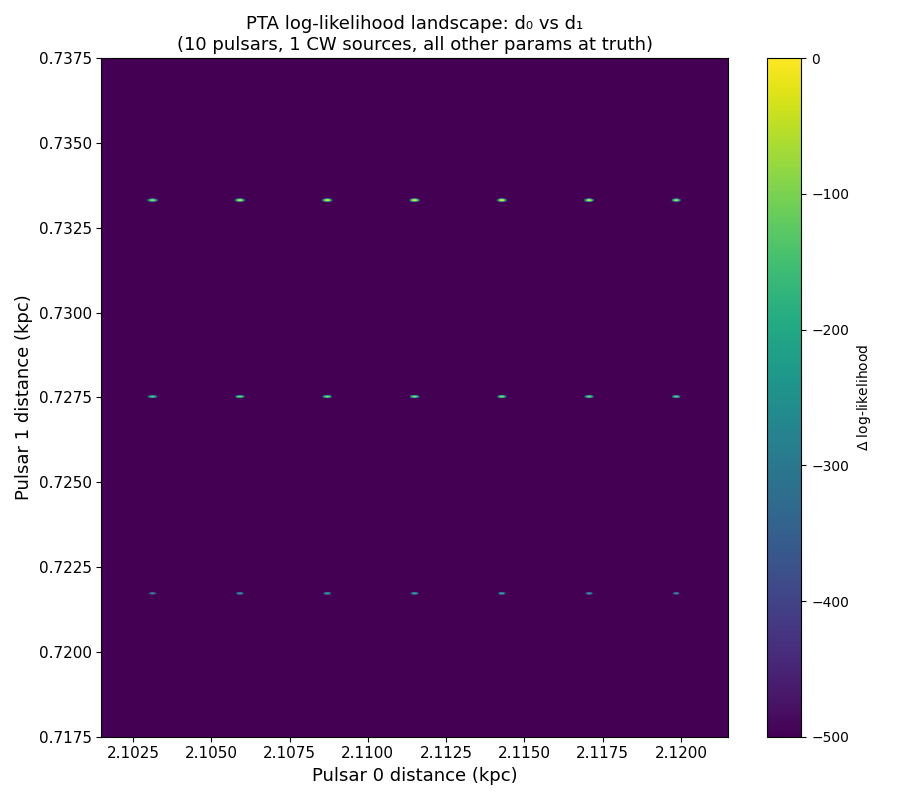

In [8]:
fig, ax = plt.subplots(figsize=(9, 8))

delta = logL_2d - logL_2d.max()
delta = np.clip(delta, -500, 0)  # shape: (N_GRID, N_GRID), rows=dist_b, cols=dist_a

mesh = ax.pcolormesh(
    np.asarray(dist_a_grid),
    np.asarray(dist_b_grid),
    delta,
    shading="auto",
    cmap="viridis",
)

#ax.plot(true_dist_a, true_dist_b, "r*", markersize=15, label="True (d\u2080, d\u2081)")

ax.set_xlabel(f"Pulsar {PULSAR_A} distance (kpc)", fontsize=13)
ax.set_ylabel(f"Pulsar {PULSAR_B} distance (kpc)", fontsize=13)
ax.set_title(
    f"PTA log-likelihood landscape: d\u2080 vs d\u2081\n"
    f"({N_PULSARS} pulsars, {M_CW_SOURCES} CW sources, all other params at truth)",
    fontsize=13,
)
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, labels, fontsize=12, loc="upper left")
ax.tick_params(labelsize=11)
fig.colorbar(mesh, ax=ax, label=r"$\Delta$ log-likelihood")
fig.tight_layout()
plt.show()

## 1D projections along each pulsar distance

Slices through `logL_2d` at the other pulsar's true distance (conditional likelihood, matching the 2D plot's "all other params at truth" convention).

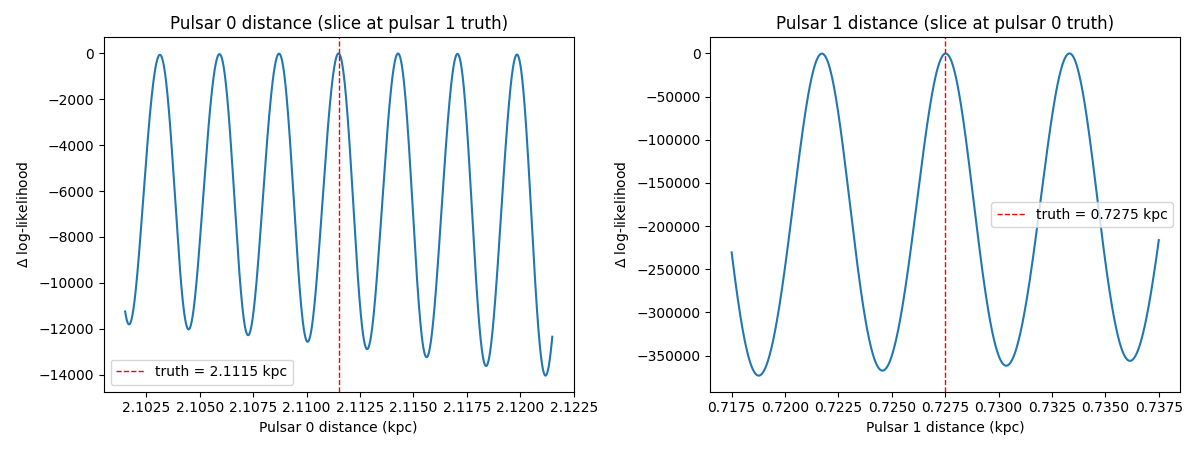

In [9]:
# Slice 2D grid at the true distance of the other pulsar.
idx_b_true = int(np.argmin(np.abs(np.asarray(dist_b_grid) - true_dist_b)))
idx_a_true = int(np.argmin(np.abs(np.asarray(dist_a_grid) - true_dist_a)))

logL_1d_a = logL_2d[idx_b_true, :]           # vs dist_a, pulsar A
logL_1d_b = logL_2d[:, idx_a_true]           # vs dist_b, pulsar B

delta_a = logL_1d_a - logL_1d_a.max()
delta_b = logL_1d_b - logL_1d_b.max()

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 4.5))

ax0.plot(np.asarray(dist_a_grid), delta_a, lw=1.5)
ax0.axvline(true_dist_a, color="r", ls="--", lw=1, label=f"truth = {true_dist_a:.4f} kpc")
ax0.set_xlabel(f"Pulsar {PULSAR_A} distance (kpc)")
ax0.set_ylabel(r"$\Delta$ log-likelihood")
ax0.set_title(f"Pulsar {PULSAR_A} distance (slice at pulsar {PULSAR_B} truth)")
ax0.legend()

ax1.plot(np.asarray(dist_b_grid), delta_b, lw=1.5)
ax1.axvline(true_dist_b, color="r", ls="--", lw=1, label=f"truth = {true_dist_b:.4f} kpc")
ax1.set_xlabel(f"Pulsar {PULSAR_B} distance (kpc)")
ax1.set_ylabel(r"$\Delta$ log-likelihood")
ax1.set_title(f"Pulsar {PULSAR_B} distance (slice at pulsar {PULSAR_A} truth)")
ax1.legend()

fig.tight_layout()
plt.show()